# Diferensiasi Numerik

Diferensiasi numerik berkaitan dengan hal sebagai berikut : 

Jika diketahui adanya sebuah fungsi $y = f(x)$ kemudian kita membutuhkan sebuah nilai turunan $y$ di titik $x = x_k$. 

Penyelesaiannya bisa dilakukan dengan algortima komputasi maupun dengan mendiskritisasi datum $(x_i,y_i), i=0,1,...,n$. Diffferensisasi ini berkaitan interpolasi, maka bisa juga dengan memperkirakan fungsi lokalnya dengan polinomial. Oleh karena itu bisanya deret Taylor $f(x)$ berperan disini untuk memperkirakan error di titik $x_k$.

Kesalahan yang biasa terjadi yaitu karena koreksi dari alat penghitung ataupun dari proses interpolasi yang dilakukan. Karena alasan ini, fungsi derivatif komputasinya tidak bisa presisi dengan fungsi derivatif ini dalam perhitungannya.

Hampir dalam semua perkerjaan numerik yang berkaitan dengan permasalahan diferensial dan intergral berlandaskan pada ekspansi Taylor. Ekspansi ini digunakan untuk menghitung nilai dari suatu fungsi disekitar titik yang diketahui melalui turunan fungsi dalam semua orde. Jika perbedaan jarak absis dari nilai yang diketahui adalah $h$. Nilai fungsi sejauh $h$ di kanan dapat dihitung melalui,
$$
\begin{aligned}
f(x+h) &= f(x) + hf'(x) + \frac{h^2}{2!}f''(x) + \frac{h^3}{3!} f'''(x) + ... \\
f(x+h) &= f(x) + hf'(x) + \sum_{k=2}^{\infty} \frac{h^i}{k!} f^{(i)}
\end{aligned}
$$
Sedangkan untuk nilai disebelah kiri dihitung melalui,
$$
\begin{aligned}
f(x-h) &= f(x) - hf'(x) + \frac{h^2}{2!}f''(x) - \frac{h^3}{3!} f'''(x) + ... \\
f(x-h) &= f(x) - hf'(x) + \sum_{k=2}^{\infty} (-1)^k\frac{h^i}{k!} f^{(i)}
\end{aligned}
$$

Dalam persamaan-persamaan diatas tanda subskrip $^{(k)}$ merepresentasikan orde dari turunan. Semakin tinggi orde dari suku turunan semakin kecil nilai hampiran numerik yang berkontribusi pada perhitungan. Maka, pada persamaan diatas, jika suku yang ditulis dengan simbol jumlah ($\sum$) dihilangkan, kita melakukan aproksimasi dengan nilai kesalahan sebesar suku yang dibuang. Dengan demikian dapat dituliskan,
$$
\begin{aligned}
f(x+h) &= f(x) + hf'(x) + \mathcal{O}(h^2) &~~~(*) \\
f(x-h) &= f(x) - hf'(x) + \mathcal{O}(h^2) &~~~(**)
\end{aligned}
$$
dengan $\mathcal{O}(h^2)$ merupakan nilai kesalahan hampiran.

## Hampiran beda-hingga

Dari ekspansi Taylor bisa didapatkan hampiran nilai turunan sebagai berikut.

1. Dari persamaan $(*)$ didapat hampiran selisih-depan (_forward difference approximation_) $$f'(x)=\frac{f(x+h)-f(x)}{h}$$
2. Dari persamaan $(**)$ didapat hampiran selisih-belakang (_backward difference approximation_) $$f'(x) = \frac{f(x)-f(x-h)}{h}$$
3. Persamaan yang ditandai dengan $(*)$ dan $(**)$ dapat dioperasikan secara aritmetika untuk mendapatkan hampiran selisih-pusat (_central difference approximation_) $$f'(x) = \frac{f(x+h)-f(x-h)}{2h}$$

## Hampiran selisih-pusat (_Central Difference Approximation_)

Diketahui bahwa solusi dari $f'(x)$ dari persamaan (4) adalah :
  $$f'(x) = \frac{f(x+h)-f(x-h)}{2h} + \mathcal{O}(h^2)$$

Persamaan ini disebut aproksimasi pertama dari central difference. Dengan penyimpangan error dalam orde $(h^2)$
Untuk turunan kedua $f''(x)$ dapat dituliskan,
$$f''(x) = \frac{f(x+h)-2f(x)+f(x-h)}{h^2} + \mathcal{O}(h^2)$$

Dengan menggunakan langkah yang sama dengan penurunan $f'(x)$, akan tetapi dengan membuang suku orde yang lebih tinggi dari 2. Turunan dengan orde yang lebih tinggi didapat dengan cara yang sama. Nilai kesalahan hampiran adalah $\mathcal{O}(h^2)$ walaupun dalam penurunan $f''(x)$ suku yang dibuang mulai dari orde-3. Ini dikarenakan $f'(x)$ disubstitusikan pulake dalam persamaan hampiran.

Untuk $n$ buah data yang tersusun sebagai berikut,
$$
\begin{array}{c|cccc}
x_i & x_1 & x_2 & ... & x_n \\
\hline
y_i & y_1 & y_2 & ... & y_n \
\end{array}
$$
persamaan hampiran selisih-pusat dituliskan,
$$
y'_i = \frac{y_{i+1} - y_{i-1}}{x_{i+1}-x_{i-1}}
$$
dengan $(x_{i+1}-x_{i-i})=2\Delta x = 2h$. Pada data yang memiliki spasi merata (_equispace_) $h=x_{i+1}-x_i$ dapat dihitung satu kali sebelim pengulangan perhitungan diperensiasi dilakukan.

Turunan kedua dituliskan,
$$
y''_i = 4\frac{y_{i+1}-2y_i+y_{i-1}}{(x_{i+1} - x_{i-1})^2}
$$
Dalam aplikasi hampiran selisih-pusat, data turunan memiliki jeda (_lag_) satu data ($h$) di awal dan di akhir data asal. Artinya, untuk $n$ buah data $y'_1$ dan $y'_n$ tidak terdefinisi. Ini memiliki keuntungan dibanding dengan hampiran selisih depan dan belakang, karena pada algoritma-algoritma itu jeda data tidak genap, karena titik turunan fungsi memiliki jeda $h/2$. Ini salah satu alasan hampiran selisih-pusat lebih nyaman digunakan, terutama jika jumlah data awal banyak.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# deklarasi fungsi
# y = 0.01x^2 + cos(0.05\pi x) -1

fx = lambda x: 0.01*x**2  + np.cos(0.05*x*np.pi) - 1
dfx = lambda x: 0.02*x - 0.05*np.pi*np.sin(0.05*x*np.pi)

n=50; err=0.000229
n=25; err=0.000457
n=10; err=0.001012


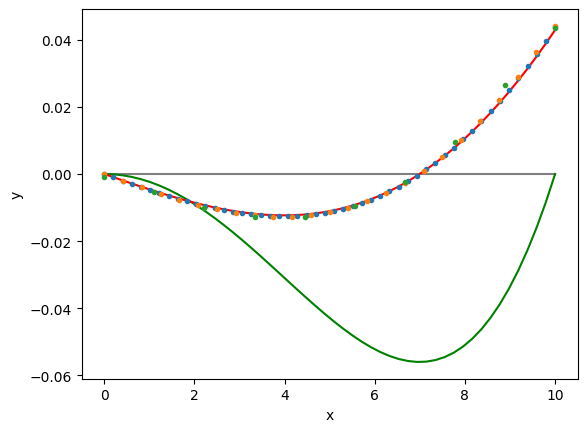

In [2]:
# turunan dengan spasi dx=h merata
# argumen y adalah data dari fungsi f(x)
def difCentral(y,h=1):
    n=len(y)
    dy=np.zeros(len(y))
    for i in range(1,n-1):
        dy[i]=(y[i+1]-y[i-1])/(2*h)

    # interpolasi garis untuk titik awal dan akhir
    dy[0]=2*dy[1]-dy[2]
    dy[-1]=2*dy[-2]-dy[-3]
    return dy

# uji coba algoritma
x=np.linspace(0, 10, 50)
# fungsi dan turunan analitik
y=fx(x)
ay = dfx(x)

plt.plot(x,np.zeros(len(x)), color='gray')
plt.plot(x,y, color='green')
plt.plot(x,ay,color='red')

for n in [50, 25, 10]:
    xx=np.linspace(0,10,n)
    yy=fx(xx)
    ay=dfx(xx)
    h=10/n
    dy=difCentral(yy,h)
    plt.plot(xx,dy, '.')
    # residual
    res=sum(np.sqrt((dy-ay)**2))/n
    print(f'n={n}; err={res:0.6f}')

plt.xlabel('x')
plt.ylabel('y')
plt.show()



## Turunan melalui fungsi interpolasi

Interpolasi dapat dilakukan pada data yang tidak rapat untuk mendapatkan fungsi malar di setiap titik. Untuk interpolasi polinomial, kurva diferensial didapat dengan menurunkan tiap suku polinomial,
$$
\begin{aligned}
P_n(x) &= \sum_{i=0}^n a_i x^i \\
\frac{d P_n}{dx} &= \sum_{i+1}^n ia_i x^{i-1}
\end{aligned}
$$
Yang harus diperhatikan dalam penggunaan interpolasi polinomial untuk mencari fungsi turunan adalah sifat osilasi artifisial yang dapat terjadi ketika $n$ besar.

Cara yang efektif untuk mendapatkan fungsi turunan dari data diskrit menggunakan fungsi interpolasi adalah dengan meningkatkan resolusi data, kemudian menghitung data turunan dari kurva interpolasi $P_n(x)$.

In [3]:
# -----> Interpolasi polinomial
def poli(x, xd, yd):
    p=0
    N=len(yd)
    for i in range(N):
        s=yd[i]
        for j in range(N):
            if i == j: continue
            s*=(x-xd[j])/(xd[i]-xd[j])
        p+=s
    return p

def interp(x, y, n):
    # domain baru dengan resolusi lebih tinggi
    xr=np.linspace(x[0], x[-1], n)
    dd=[]
    for xi in xr:
        dd.append(poli(xi, x, y))

    return xr, np.array(dd)
#----------<

kesalahan residu: 0.000112


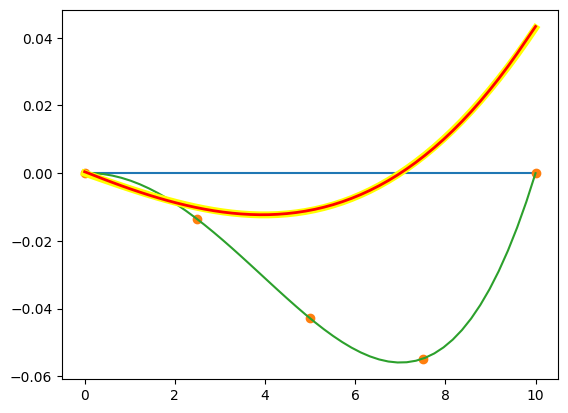

In [4]:
# lakukan sampling pada fungsi awal

x=np.linspace(0,10,5)
y=fx(x)
n=50
px,py=interp(x,y,n)
ay=dfx(px)
h=(px[-1]-px[0])/(len(px)-1)
dy=difCentral(py,h)
res=sum(np.sqrt((dy-ay)**2))/n
print(f'kesalahan residu: {res:0.6f}')

plt.plot(x,np.zeros(len(x)))
plt.plot(x,y,'o')
plt.plot(px,py)
plt.plot(px,ay, linewidth=5, color='yellow')
plt.plot(px,dy, linewidth=2, color='red')
plt.show()

Perhatikan bahwa dengan menggunakan metode ini kesalahan residual dari perhitungan turunan menjadi lebih kecil, hanya dengan menggunakan jumlah sampling yang kecil (5 titik).

### Turunan menggunakan kurva spline

Perhitungan interpolasi menggunakan kurva spline dilakukan per-segmen data, dengan memastikan kontinuitas pada titik-titik ujung segmen. Untuk kubik-spline, hubungan diferensial berikut harus terpenuhi pada batas segmen,
$$
\begin{aligned}
g_i'(x_{i+1}) &= g_{i+1}'(x_i) \\
g_i''(x_{i+1}) &= g_{i+1}''(x_i)
\end{aligned}
$$
dengan $g_i$ merepresentasikan fungsi polinomial orde-3 pada segmen ke-$i$. Dengan demikian kurva spline dijamin kontiyu hanya sampai turunan ke-2.

Algoritma perhitungan interpolasi spline memberikan array dari parameter-parameter polinomial setiap segmen. Sehingga untuk membaca nilai pada titik $x$ didalam segmen, dilakukan,
$$
g_i(x) = a_ix^3 + b_ix^2 + c_ix +d_i
$$
dan turunan dari $P(x)$,
$$g_i'(x) = 3a_ix^2 + 2b_ix +c_i$$

Namun kehati-hatian harus diambil pada daerah batas, karena Spline biasa menggunakan syarat kontinuitas batas $g'_i(x)=0$ (_natural cubic spline_). Metode ini dapat dengan baik digunakan untuk titik sampling yang banyak.

In [48]:
# Dekomposisi LU untuk matriks tridiagonal
# c, d, e --> vektor kiri, diagonal, dan kanan
def LUdecomp3(c,d,e):
    n = len(d)
    for k in range(1,n):
        lam = c[k-1]/d[k-1]
        d[k] = d[k] - lam*e[k-1]
        c[k-1] = lam
    return c,d,e

# menyelesaikan persamaan
# b --> vektor konstanta
def LUsolve3(c,d,e,b):
    n = len(d)
    for k in range(1,n):
        b[k] = b[k] - c[k-1]*b[k-1]
    b[n-1] = b[n-1]/d[n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - e[k]*b[k+1])/d[k]
    return b

def koef(xd,yd):
    n = len(xd) - 1
    c = np.zeros(n)
    d = np.ones(n+1)
    e = np.zeros(n)
    k = np.zeros(n+1)
    c[0:n-1] = xd[0:n-1] - xd[1:n]
    d[1:n] = 2.0*(xd[0:n-1] - xd[2:n+1])
    e[1:n] = xd[1:n] - xd[2:n+1]
    k[1:n] = 6.0*(yd[0:n-1] - yd[1:n]) \
            /(xd[0:n-1] - xd[1:n]) - 6.0*(yd[1:n] - yd[2:n+1]) \
            /(xd[1:n] - xd[2:n+1])
    
    LUdecomp3(c,d,e)
    LUsolve3(c,d,e,k)
    return k

def Spline(xd, yd, k, nres):
    
    def iseg(xd,x): 
        i0,i1 = 0,len(xd)- 1
        while True:
            if (i1-i0) <= 1: return i0
            i=(i0 + i1)//2
            if x < xd[i]: i1 = i
            else: i0 = i
    
    xx=np.linspace(xd[0], xd[-1], nres)
    y=np.zeros(nres)
    dy=np.zeros(nres)

    for i in range(len(xx)):
        x=xx[i]
        ix = iseg(xd,x)
        h = xd[ix] - xd[ix+1]
        
        y[i] = ((x - xd[ix+1])**3/h - (x - xd[ix+1])*h)*k[ix]/6.0 \
            - ((x - xd[ix])**3/h - (x - xd[ix])*h)*k[ix+1]/6.0 \
            + (yd[ix]*(x - xd[ix+1]) \
            - yd[ix+1]*(x - xd[ix]))/h
        
        dy[i] = (3*(x - xd[ix+1])**2/h - (xd[ix]-xd[ix+1]))*k[ix]/6 \
            - (3*(x-xd[ix])**2/h - h)*k[ix+1]/6 \
            + (yd[ix]-yd[ix+1])/h
    
    return xx,y,dy


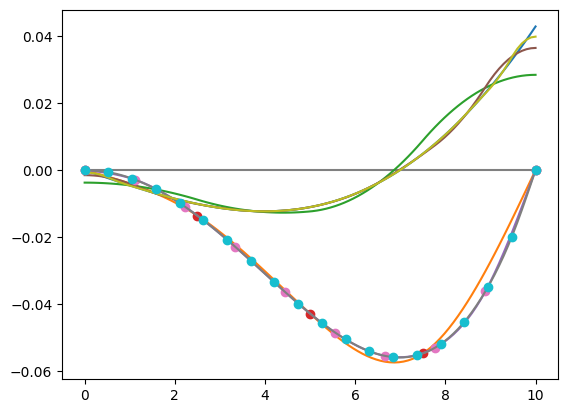

In [49]:

x=np.linspace(0,10,100)
plt.plot(x,dfx(x))
plt.plot([x[0],x[-1]],[0,0], color='gray')

for nsample in [5,10,20]:
    x=np.linspace(0,10,nsample)
    y=fx(x)
    k=koef(x,y)
    xx,yy,dy=Spline(x,y,k,100)
    plt.plot(xx,yy)
    plt.plot(xx,dy)
    plt.plot(x,y,'o')

plt.show()